In [1]:
import importlib
import util
import data
importlib.reload(util)
importlib.reload(data)

<module 'data' from 'c:\\Users\\janav\\Documents\\load forecasting\\local-stlf\\wavelet-transform\\data.py'>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from util import evaluate_model, autoregressive_forecast_strict, calculate_metrics
import time
from data import prepare_data
import torch

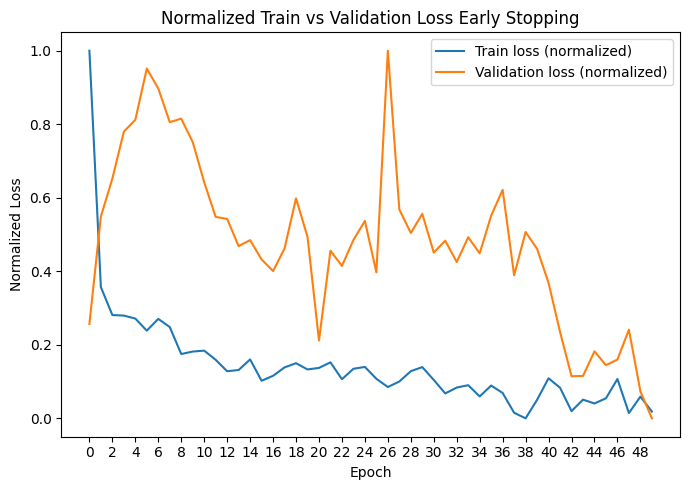

In [3]:
df = pd.read_csv('logs/training_log.csv')

df['val_loss'] = df['val_loss'].astype(float)
df['train_loss'] = df['train_loss'].astype(float)

# Min-max normalization
train_min = df['train_loss'].min()
train_max = df['train_loss'].max()
val_min = df['val_loss'].min()
val_max = df['val_loss'].max()

df['train_loss_norm'] = (df['train_loss'] - train_min) / (train_max - train_min)
df['val_loss_norm'] = (df['val_loss'] - val_min) / (val_max - val_min)

epochs = range(len(df))

plt.figure(figsize=(7, 5))
plt.plot(epochs, df['train_loss_norm'].values, label="Train loss (normalized)")
plt.plot(epochs, df['val_loss_norm'].values, label="Validation loss (normalized)")
plt.title("Normalized Train vs Validation Loss Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Normalized Loss")
plt.xticks(range(0, len(df), 2))  # ticks every 2 epochs
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
args = {
    "test": 0.3,  # test/val split ratio
    "val": 0.1, 
    "horizon": 8,      # horizon=2 only due to SWT even-length requirement.
    "lookback": 24 * 14,
    "epochs": 20,  
    "batch_size": 64,
    "level": 3,  # user-defined max SWT level
    "wavelet": "db2"
}

train_loader, val_loader, test_loader, ys, scalers_X, scalers_y, X_train_tensors, X_val_tensors, X_test_tensors = prepare_data(args)
_, _, y_test = ys

In [5]:
def plot_input_bands_from_tensors(X_train_tensors, n_samples=5):
    import matplotlib.pyplot as plt

    n_bands = len(X_train_tensors)
    fig, axs = plt.subplots(n_samples, n_bands, figsize=(4 * n_bands, 3 * n_samples), squeeze=False)

    for i in range(n_samples):
        for j in range(n_bands):
            seq = X_train_tensors[j][i].cpu().detach().numpy().squeeze()
            axs[i][j].plot(seq)
            axs[i][j].set_title(f"Sample {i}, Band {j}")
            axs[i][j].grid(True)

    plt.tight_layout()
    plt.show()

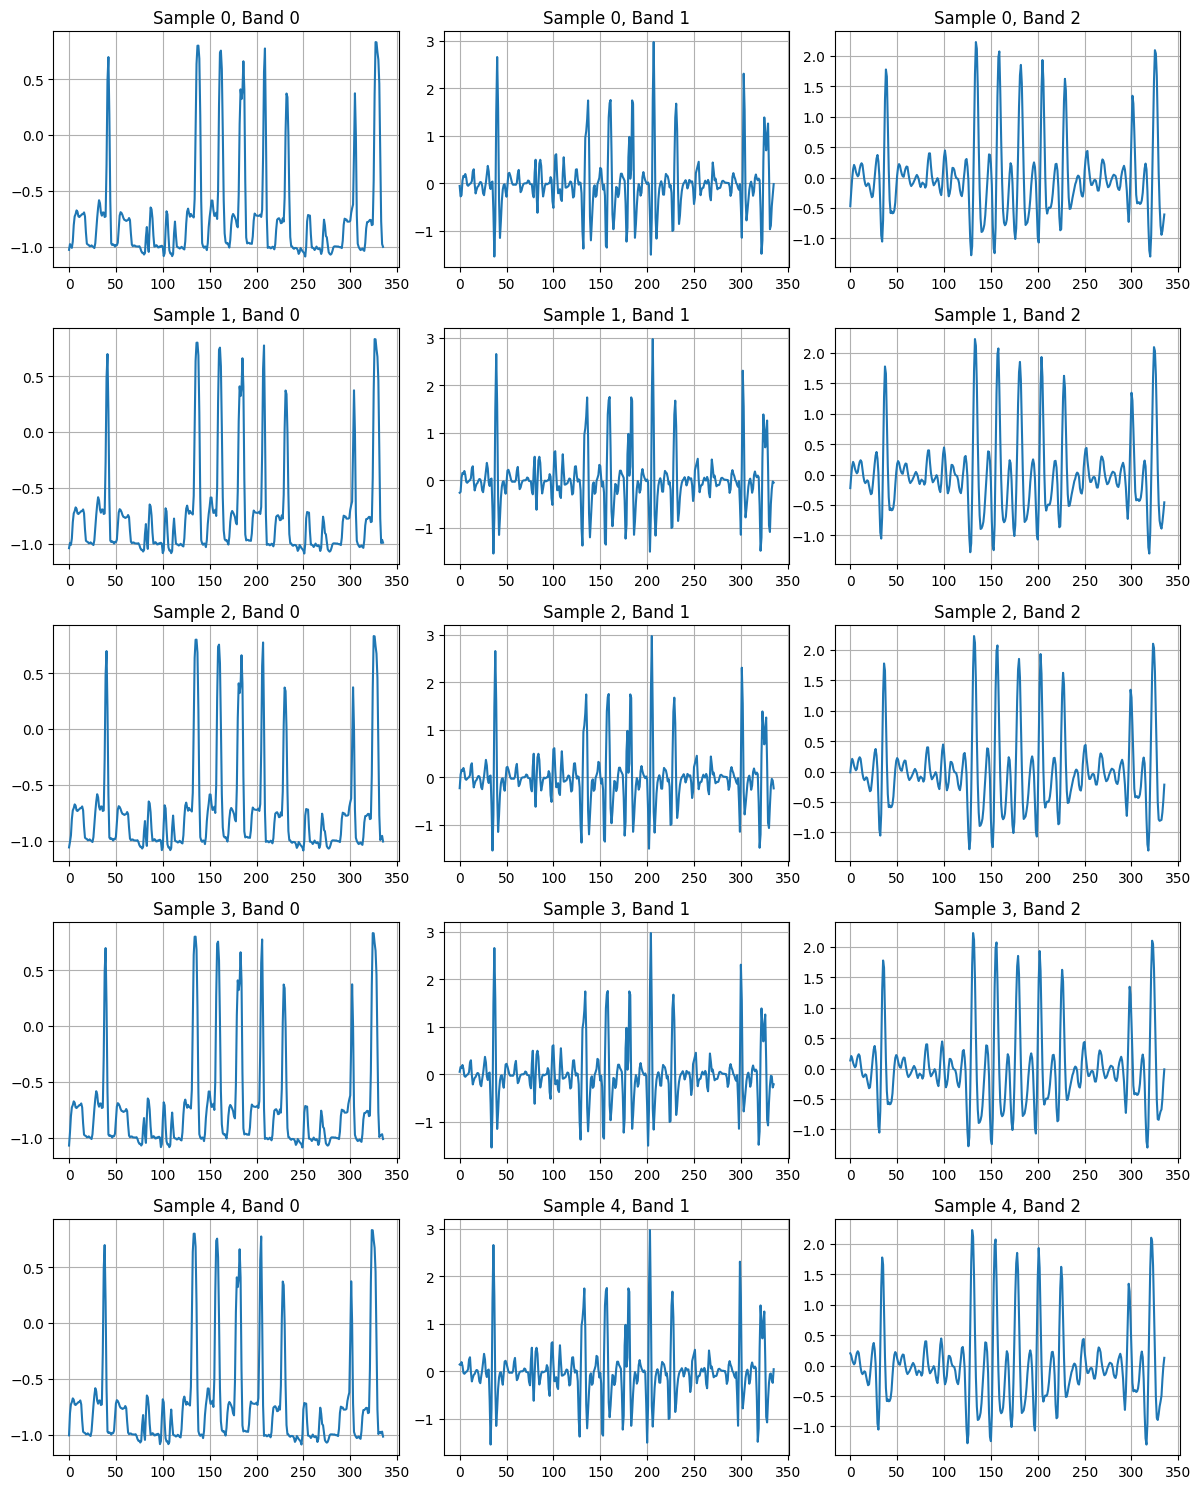

In [6]:
plot_input_bands_from_tensors(X_train_tensors)

In [7]:
def plot_band_histograms(X_train_tensors, bins=50):
    n_bands = len(X_train_tensors)
    plt.figure(figsize=(5 * n_bands, 4))

    for i in range(n_bands):
        data = X_train_tensors[i].cpu().detach().numpy().flatten()
        plt.subplot(1, n_bands, i + 1)
        plt.hist(data, bins=bins, alpha=0.7, edgecolor='black')
        plt.title(f'Band {i} Histogram')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

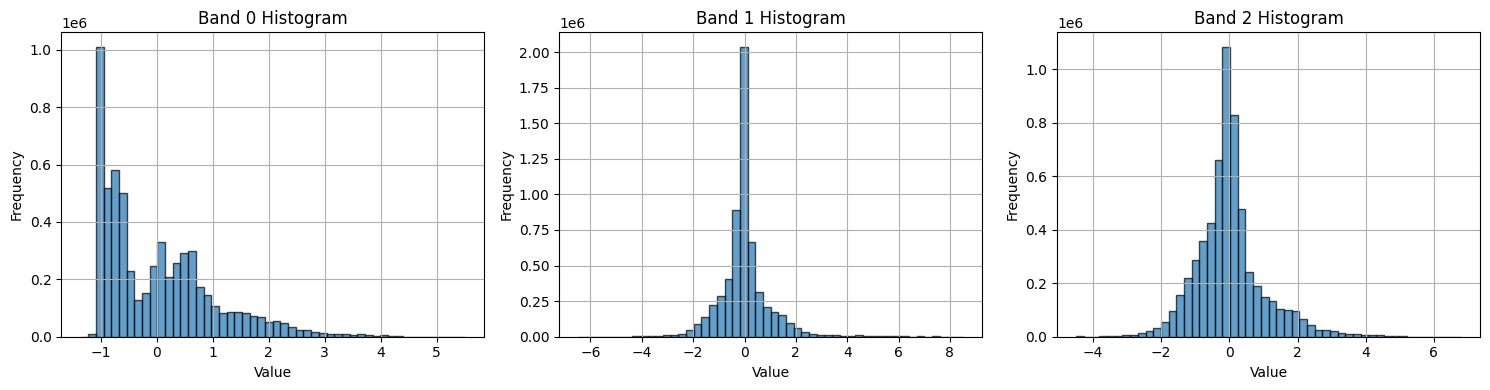

In [8]:
plot_band_histograms(X_train_tensors)

In [9]:
model = torch.load('models/model_epoch_20.pt')

C:\Users\janav\AppData\Local\Temp\ipykernel_25900\1707764512.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('models/model_epoch_20.pt')


In [10]:
y_pred, st_metrics = evaluate_model(
    model,
    test_loader,
    y_test,
    scalers_y[0],
    args['horizon'],
    data_type='st',
    wavelet=args['wavelet']
)

In [11]:
y_pred.max(), y_pred.min()

(3.5012372, 0.7336987)

In [12]:
def plot_data(y_true, y_pred):
    plt.figure(figsize=(30, 7))
    plt.plot(y_true, color='blue', linewidth=0.5, label='True Values (t+1)')
    plt.plot(y_pred, color='red', linewidth=0.5, label='Predicted Values (t+1)')
    plt.title("Forecast Step t+1: Predicted vs True")
    plt.xlabel("Time Step")
    plt.ylabel("Rescaled Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

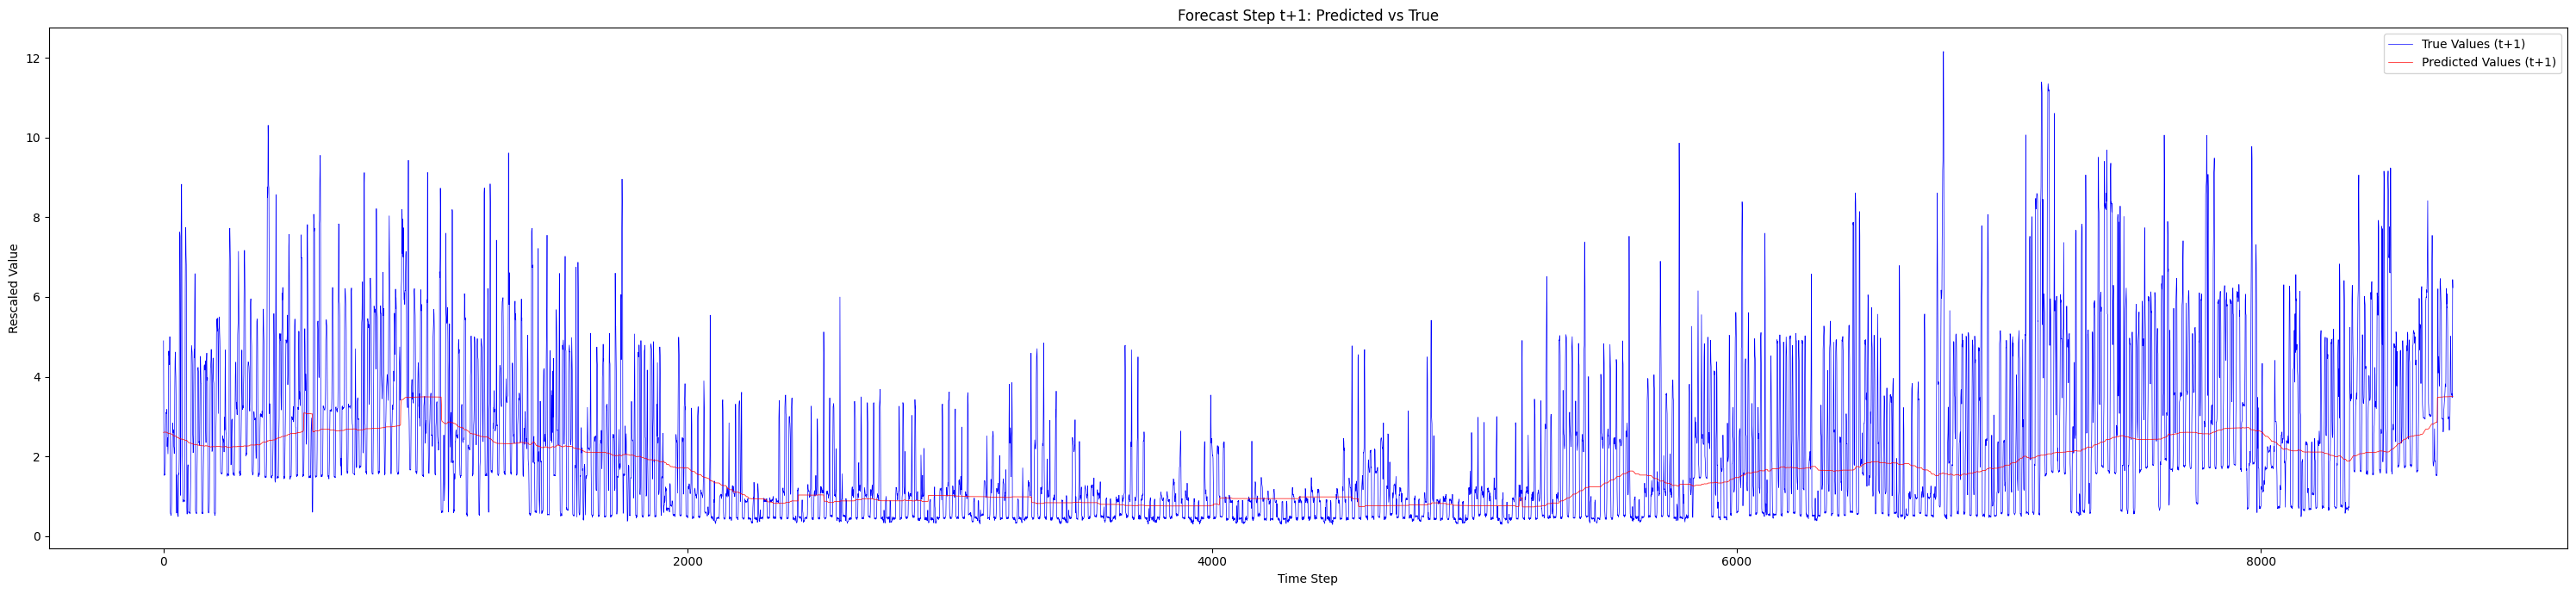

In [13]:
plot_data(y_test[:, 0], y_pred)

In [14]:
start = time.time()
y_auto = autoregressive_forecast_strict(
    model, val_loader, scalers_y[0], y_test,
    lookback=args['lookback'], forecast_steps=args['horizon'], wavelet='db2', level=3
)
end = time.time()
y_trimmed = y_test[:len(y_auto), 0]
lt_metrics = calculate_metrics(y_trimmed, y_auto, elapsed_time=time.time() - start, type='lt')

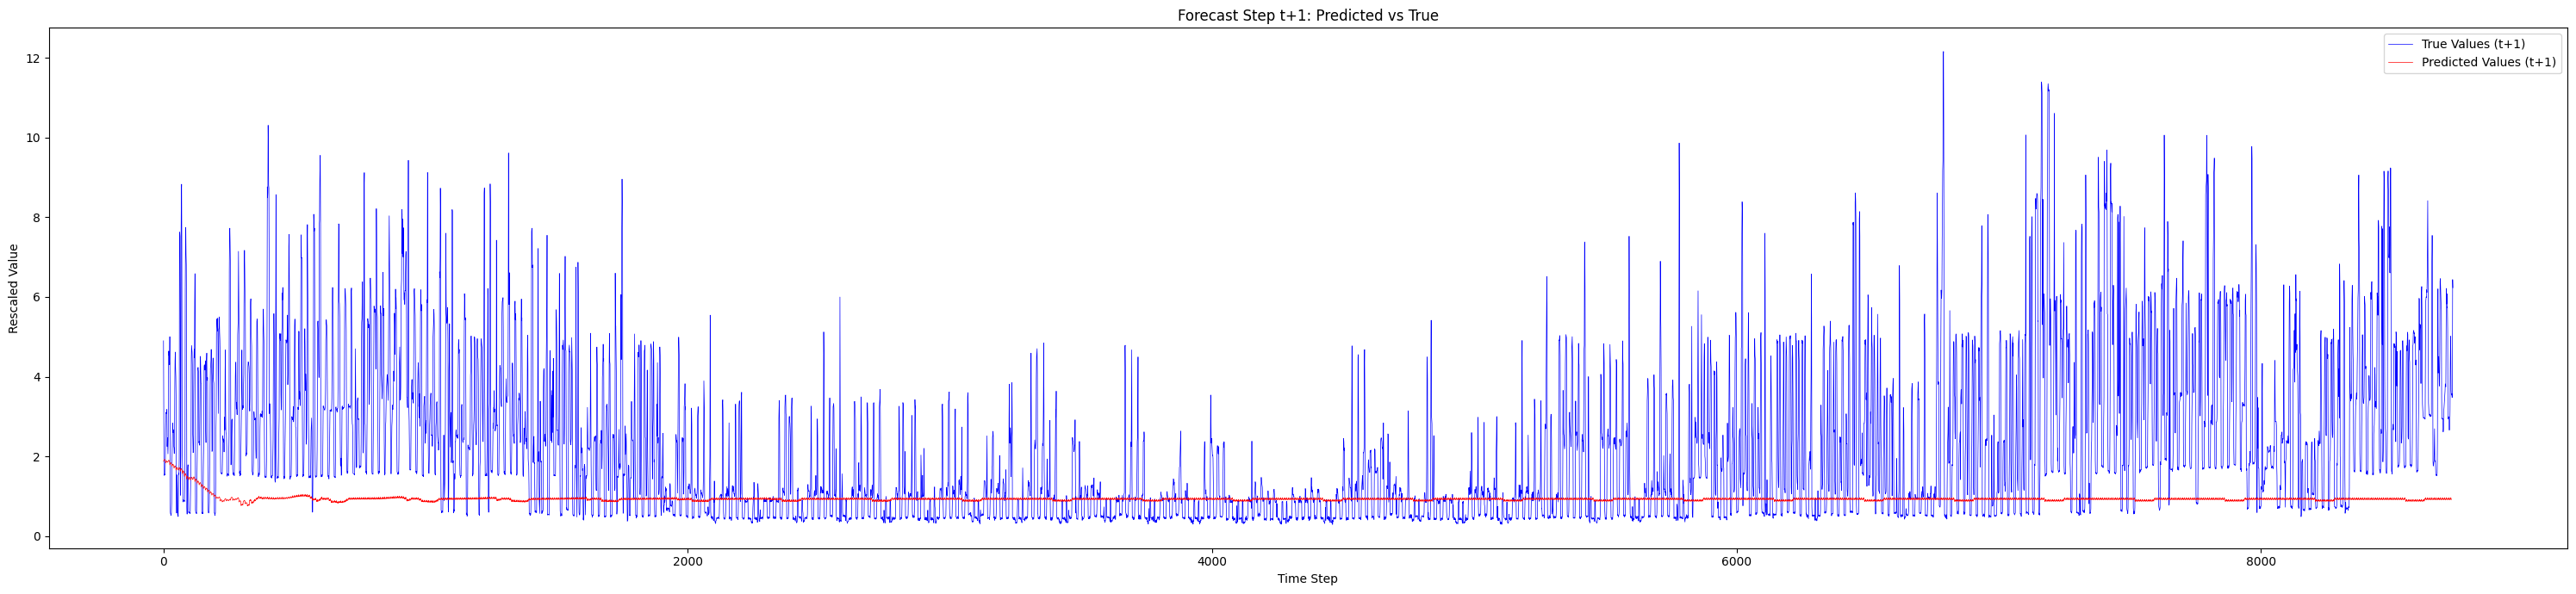

In [15]:
plot_data(y_test[:, 0], y_auto)

In [16]:
results_df = pd.concat([pd.DataFrame([st_metrics]), pd.DataFrame([lt_metrics])], axis=0)
df_preds = pd.DataFrame({
    'y_true': y_test[:len(y_auto), 0],
    'y_st': y_pred[:len(y_auto)],
    'y_lt': y_auto
})
df_preds.to_csv('logs/prediction_data.csv', index=False)
results_df.to_csv('logs/prediction_eval.csv', index=False)